In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis_lexi_age_grouped")
output_folder.mkdir(exist_ok=True)

In [49]:
dict_with_all_datasets = {}


columns_to_remove = ["distance_relationship_type", "generative_rule", "num_iterations", "preferential_relationship_type", 
                         "id", "network_idx", "network_index", 
                         "mc_values_for_indiv_lags"]

for dataset_name in ["hcp_schaefer_100_dataset"]:
    
    experiment_name_gnm = "11_mst_2500_animal_0"
    base_path_gnm = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name_gnm}")
    precise_gnm_files = {
                        "fundamental": f"all_metrics_for_{experiment_name_gnm}.csv", 
                        "static": f"all_static_metrics_for_{experiment_name_gnm}_updated.csv", 
                        "dynamic": f"all_dynamic_metrics_for_{experiment_name_gnm}_updated.csv", 
                        "computational": f"all_computational_metrics_for_{experiment_name_gnm}_updated.csv", 
                        "further": f"all_further_metrics_for_{experiment_name_gnm}_updated.csv", 
                        }

    # Combine them all to one big dataframe. The indeces correspond to same entries across the different metric types, so we can easily merge them. Check first if the dfs are equally long. 
    dfs_gnm = {key: pd.read_csv(base_path_gnm / file) for key, file in precise_gnm_files.items()}
    lengths_gnm = {key: len(df) for key, df in dfs_gnm.items()}
    print(lengths_gnm)
    # They are all equally long, so we can merge them together (eta, gamma, id) 
    df_gnm = dfs_gnm["fundamental"]  # Start with the fundamental df as the base
    for key in precise_gnm_files.keys():
        if key == "fundamental":
            continue  # Skip the fundamental df since it's already our base
        print(key)
        df_gnm = df_gnm.merge(dfs_gnm[key], on=["eta", "gamma", "id"], how="left", suffixes=("", f"_{key}"))
        
    # df_gnm = pd.concat(dfs_gnm.values(), axis=1)
    # Check if there are duplicate columns after merging. If so, we can drop them - but print them first to see which ones they are.
    duplicate_columns_gnm = df_gnm.columns[df_gnm.columns.duplicated()]
    print("Attention: Duplicate entries (got removed from the 'previous' df):", duplicate_columns_gnm)
    # Drop the duplicate columns. We want to delete the ones from the "previous" df
    df_gnm = df_gnm.loc[:, ~df_gnm.columns.duplicated()]
        
    # Remove columns if all their entries are empty 
    df_gnm = df_gnm.dropna(axis=1, how="all")
    
    # dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].drop(columns=["repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", 
    #                                                                  "repertoire_sweep_weighted_by_distances_T_vec", "repertoire_sweep_weighted_by_distances_sizes", "repertoire_sweep_weighted_by_distances_diversities", 
    #                                                                  "repertoire_sweep_T_critical", "repertoire_sweep_size_critical", "repertoire_sweep_diversity_critical" # "repertoire_sweep_weighted_by_distances_T_critical", "repertoire_sweep_weighted_by_distances_size_critical"
    #                                                                  ], inplace=True, errors="ignore")
    # drop "repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", if those columns are present in the df, since they are not relevant for the analysis and they have many missing values.
    for col in ["repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", 
                "repertoire_sweep_weighted_by_distances_T_vec", "repertoire_sweep_weighted_by_distances_sizes", "repertoire_sweep_weighted_by_distances_diversities",
                "repertoire_sweep_T_critical", "repertoire_sweep_size_critical", "repertoire_sweep_diversity_critical", 
                "departure_from_normality", # As this one has nones now??? TODO. 
                "proportion_long_range_connections_0.356"
                ]:
        if col in df_gnm.columns:
            df_gnm = df_gnm.drop(col, axis=1)
            print(f"Dropped column '{col}' from '{dataset_name}' because it had many missing values and is not relevant for the analysis.")
        else:
            print(f"Column '{col}' not found in '{dataset_name}', so it was not dropped.")

    # Remove unimportant columns
    columns_to_remove += [col for col in df_gnm.columns if col.startswith("h_params")]
    df_gnm = df_gnm.drop(columns=[col for col in columns_to_remove if col in df_gnm.columns])

    # Check the shape of the final df
    print(df_gnm.shape)

    dict_with_all_datasets[dataset_name+"_gnm"] = df_gnm
    
    

for dataset_name in emp_dataset_and_experiment_pairs:
    
    if dataset_name == "hcp_schaefer_100_dataset_gnm":
        continue  # We already processed the gnm data for this dataset, so we skip it here.
    
    # Do the same thing for the empirical data.
    experiment_name_emp = emp_dataset_and_experiment_pairs[dataset_name]
    base_path_emp = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name_emp}")
    precise_emp_files = {"static": f"metrics_2_static.csv", 
                         "dynamic": f"metrics_2_dynamic.csv",
                         "computational": f"metrics_2_computational.csv",
                         "further": f"metrics_2_further.csv"}
    
    # Combine them all to one big dataframe. The indeces correspond to same entries across the different metric types, so we can easily merge them. Check first if the dfs are equally long. 
    dfs = {key: pd.read_csv(base_path_emp / file) for key, file in precise_emp_files.items()}
    lengths = {key: len(df) for key, df in dfs.items()}
    print(lengths)
    # They are all equally long, so we can merge them on the index.
    # df = pd.concat(dfs.values(), axis=1)
    df = dfs["static"]  # Start with the static df as the base
    for key in precise_emp_files.keys():
        if key == "static":
            continue  # Skip the static df since it's already our base
        print(key)
        df = df.merge(dfs[key], left_index=True, right_index=True, how="left", suffixes=("", f"_{key}"))
    
        
    # Rename columns: strip "basic_measures_" prefix where present
    df.columns = [col.replace("basic_measures_", "") if col.startswith("basic_measures_") else col for col in df.columns]
    
    # Rename columns: strip "mc_original_" prefix where present
    df.columns = [col.replace("mc_original_", "") if col.startswith("mc_original_") else col for col in df.columns]

    # Check if there are duplicate columns after merging. If so, we can drop them - but print them first to see which ones they are.
    duplicate_columns_emp = df.columns[df.columns.duplicated()]
    print("Attention: Duplicate entries (did not get removed so far):", duplicate_columns_emp)
    # Remove exact-duplicate columns (content-identical), keep first occurrence
    cols_to_keep = []
    seen = {}
    for i, col in enumerate(df.columns):
        if col not in seen:
            seen[col] = i
            cols_to_keep.append(i)
        else:
            # Check if the duplicate column is identical in content
            if df.iloc[:, seen[col]].equals(df.iloc[:, i]):
                print(f"  -> Dropping identical duplicate column: '{col}'")
            else:
                # Keep both but rename the duplicate
                new_name = f"{col}_dup"
                df.columns.values[i] = new_name
                cols_to_keep.append(i)
                print(f"  -> Kept non-identical duplicate column '{col}' as '{new_name}'")
    df = df.iloc[:, cols_to_keep]
    
    # drop "repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", if those columns are present in the df, since they are not relevant for the analysis and they have many missing values.
    for col in ["repertoire_sweep_T_vec", "repertoire_sweep_sizes", "repertoire_sweep_diversities", 
                "repertoire_sweep_weighted_by_distances_T_vec", "repertoire_sweep_weighted_by_distances_sizes", "repertoire_sweep_weighted_by_distances_diversities", 
                "repertoire_sweep_T_critical", "repertoire_sweep_size_critical", "repertoire_sweep_diversity_critical", 
                "proportion_long_range_connections_0.356", 
                "repertoire_diversity", "repertoire_size", 
                "departure_from_normality" # As this one has nones now??? TODO. 
                ]:
        if col in df.columns:
            df = df.drop(col, axis=1)
            print(f"Dropped column '{col}' from '{dataset_name}' because it had many missing values and is not relevant for the analysis.")
        else:
            print(f"Column '{col}' not found in '{dataset_name}', so it was not dropped.")

            
    # Remove columns if all their entries are empty 
    df = df.dropna(axis=1, how="all")

    # if there is n_components in the df, then exclude the rows where n_components != 1 and print the row ids 
    if "n_connected_components" in df.keys():          
        # Get all rows where n_connected_components != 1; print them and exclude them
        non_singleton_components = df[df['n_connected_components'] != 1]
        indices_to_remove = non_singleton_components.index.tolist()
        if len(indices_to_remove) > 0: 
            print("⚠️ Non-singleton components. IDs that are going to be removed: ", indices_to_remove) #  "their 'network_id' or similar values:", non_singleton_components[["id", "network_index", "network_idx"]]))
            # df = df[df['n_connected_components'] == 1]
            df = df[~df.index.isin(indices_to_remove)]
            print(" ---> Done. New df length:", len(df))
        
    # Remove unimportant columns
    columns_to_remove += [col for col in df.columns if col.startswith("h_params")]
    df = df.drop(columns=[col for col in columns_to_remove if col in df.columns])


    # Check the shape of the final df   
    print(df.shape)
    dict_with_all_datasets[dataset_name] = df
    

# SAVE THE DICT 
with open(output_folder / "all_datasets_lexi_age_grouped.pkl", "wb") as f:
    pickle.dump(dict_with_all_datasets, f)


{'fundamental': 25000, 'static': 25000, 'dynamic': 25000, 'computational': 25000, 'further': 25000}
static
dynamic
computational
further
Attention: Duplicate entries (got removed from the 'previous' df): Index([], dtype='object')
Dropped column 'repertoire_sweep_T_vec' from 'hcp_schaefer_100_dataset' because it had many missing values and is not relevant for the analysis.
Dropped column 'repertoire_sweep_sizes' from 'hcp_schaefer_100_dataset' because it had many missing values and is not relevant for the analysis.
Dropped column 'repertoire_sweep_diversities' from 'hcp_schaefer_100_dataset' because it had many missing values and is not relevant for the analysis.
Dropped column 'repertoire_sweep_weighted_by_distances_T_vec' from 'hcp_schaefer_100_dataset' because it had many missing values and is not relevant for the analysis.
Dropped column 'repertoire_sweep_weighted_by_distances_sizes' from 'hcp_schaefer_100_dataset' because it had many missing values and is not relevant for the analy

In [50]:
selected_datasets_for_all_dataset_dict = { # No repeting data 
    "hcp_schaefer_100_dataset_gnm": "HCP (GNM)",
    
    "lexis_data_developing_consensus_per_age_1_year": "Developing (Consensus, 1 Year)",
    "lexis_data_young_consensus_per_age_1_year": "Young (Consensus, 1 Year)",
    "lexis_data_aging_consensus_per_age_1_year": "Aging (Consensus, 1 Year)",
    "lexis_data_all_consensus_per_age_1_year": "All (Consensus, 1 Year)",
    "lexis_data_all_consensus_per_age_2_year": "All (Consensus, 2 Year)",
}

selected_datasets_for_all_dataset_arr = selected_datasets_for_all_dataset_dict.keys()

# have all_datase_dict only have keys that are in selected_datasets_for_all_dataset_arr
dict_with_all_datasets = {key: dict_with_all_datasets[key] for key in selected_datasets_for_all_dataset_arr if key in dict_with_all_datasets}


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis_lexi_age_grouped/gnm_property_heatmaps.pdf


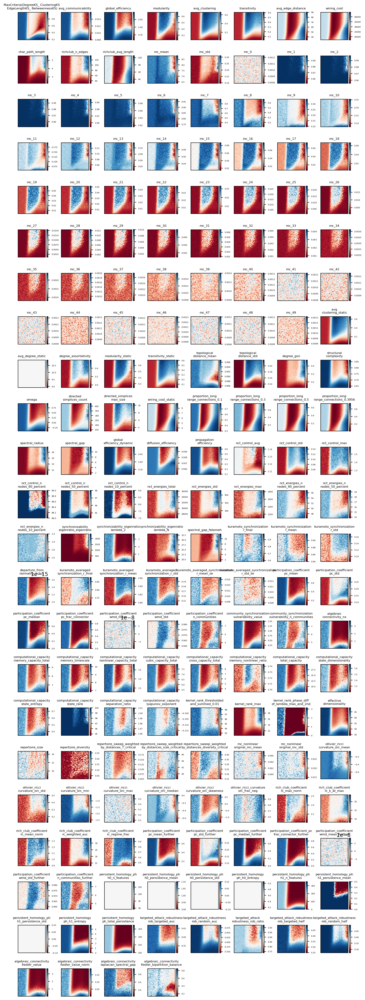

In [51]:
# df_gnm_g = df_gnm.groupby(["eta", "gamma"]).mean().reset_index()
df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index() #

# EXCLUDE COLUMNS: 
constant_columns = ["avg_degree", "n_connected_components", "density", "density_bct", "kernel_rank_phase_of_lambda_max"]
df_gnm_g = df_gnm_g.drop(columns=[col for col in constant_columns if col in df_gnm_g.columns])

cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]
len(cols_of_interest)


n_cols = 8 
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 3)), sharex=True, sharey=True, dpi=200)
for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    im = ax.imshow(df_gnm_g.pivot(index="gamma", columns="eta", values=col),
                   aspect="equal", origin="lower", 
                   cmap="RdBu" # viridis" "berlin"
                )

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:  
        col = re.split(r'[,,_]+', col) # THIS IS OBV UGGLY: SEE ENERGY!! TODO Add comata again
        # col = col.split("_")
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=4) 

# remove empty subplots
for idx in range(len(cols_of_interest), n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
plt.tight_layout(pad=0.4)

plt.savefig(output_folder / "gnm_property_heatmaps.pdf", dpi=200)
print(output_folder / "gnm_property_heatmaps.pdf")


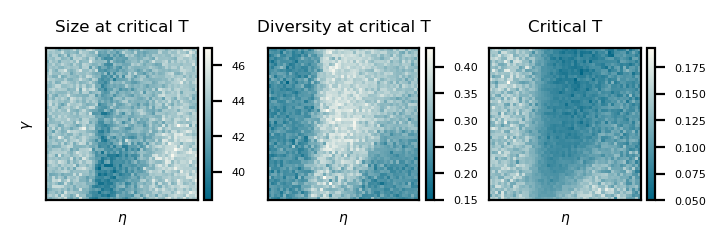

In [52]:

df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index()
    
columns_of_interest = ["repertoire_sweep_weighted_by_distances_size_critical",
                      "repertoire_sweep_weighted_by_distances_diversity_critical",
                      "repertoire_sweep_weighted_by_distances_T_critical" 
                      ]

titles_of_interest = ["Size at critical T", "Diversity at critical T", "Critical T"]
n_cols = 3
n_rows = 2 # np.max((len(columns_of_interest) + n_cols - 1) // n_cols, 2) 
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 3)), sharex=True, sharey=True, dpi=200)
for idx, col in enumerate(columns_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    # im = ax.imshow(df_gnm_g.pivot(index="gamma", columns="eta", values=col)-df_gnm_g.pivot(index="gamma", columns="eta", values="spectral_gap"),
    #                aspect="equal", origin="lower", cmap="viridis")
    im = ax.imshow(df_gnm_g.pivot(index="gamma", columns="eta", values=col),
                   aspect="equal", origin="lower", 
                   cmap=viz.give_colormaps()["bw_db"].reversed()) # gray_cmap) #  cmap="viridis") # energy_blue_beige"].reversed()) # 

    # if the title is too long (define this), then split it into two lines at the last underscore
    col = PROPERTY_NAMES[col]
    if len(col) > 20:  
        col = re.split(r'[,,_,:]+', col) # THIS IS OBV UGGLY: SEE ENERGY!! TODO Add comata again
        # col = col.split("_")
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(titles_of_interest[idx], fontsize=6) # col, fontsize=6)

    ax.set_xticks([])
    ax.set_yticks([])
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=4) 

    if idx == 0:
        ax.set_ylabel(r"$\gamma$", fontsize=5)
    ax.set_xlabel(r"$\eta$", fontsize=5)

# remove empty subplots
for idx in range(idx+1, n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
plt.tight_layout(pad=0.4)

In [53]:
print("Fundamental mc cols:", [c for c in dfs_gnm["fundamental"].columns if "mc_" in c])
print("Computational mc cols:", [c for c in dfs_gnm["further"].columns if "mc_" in c])
print("Computational mc cols:", [c for c in dfs_gnm["computational"].columns if "mc_" in c])

Fundamental mc cols: ['mc_mean', 'mc_std', 'mc_0', 'mc_1', 'mc_2', 'mc_3', 'mc_4', 'mc_5', 'mc_6', 'mc_7', 'mc_8', 'mc_9', 'mc_10', 'mc_11', 'mc_12', 'mc_13', 'mc_14', 'mc_15', 'mc_16', 'mc_17', 'mc_18', 'mc_19', 'mc_20', 'mc_21', 'mc_22', 'mc_23', 'mc_24', 'mc_25', 'mc_26', 'mc_27', 'mc_28', 'mc_29', 'mc_30', 'mc_31', 'mc_32', 'mc_33', 'mc_34', 'mc_35', 'mc_36', 'mc_37', 'mc_38', 'mc_39', 'mc_40', 'mc_41', 'mc_42', 'mc_43', 'mc_44', 'mc_45', 'mc_46', 'mc_47', 'mc_48', 'mc_49']
Computational mc cols: []
Computational mc cols: ['mc_nonlinear_original_mc_mean', 'mc_nonlinear_original_mc_std']


In [54]:
# Quick overview of what's in each dataset 
print("\n" + "=" * 60)
print("Datasets loaded:")
for name in dict_with_all_datasets:
    print(f"  {name}: {dict_with_all_datasets[name].shape}")


Datasets loaded:
  hcp_schaefer_100_dataset_gnm: (25000, 187)
  lexis_data_developing_consensus_per_age_1_year: (17, 181)
  lexis_data_young_consensus_per_age_1_year: (17, 182)
  lexis_data_aging_consensus_per_age_1_year: (57, 175)
  lexis_data_all_consensus_per_age_1_year: (86, 174)
  lexis_data_all_consensus_per_age_2_year: (44, 174)


In [55]:
# Make a nice comparison table: which properties each dataset has
# Collect all unique column names across datasets
all_columns = set()
for df in dict_with_all_datasets.values():
    all_columns.update(df.columns)
all_columns = sorted(all_columns)

# Build a presence table
presence_table = pd.DataFrame(index=all_columns, columns=list(dict_with_all_datasets.keys()))
for dataset_name, df in dict_with_all_datasets.items():
    for col in all_columns:
        presence_table.loc[col, dataset_name] = "y" if col in df.columns else "missing"

presence_table.rename(columns=LABEL_MAP, inplace=True)

print("\n" + "=" * 60)
print("Property presence table:")
print(presence_table.to_string())

# Save the table to CSV
presence_table.to_csv(output_folder / "property_presence_table.csv")
print(output_folder / "property_presence_table.csv")
print("\nSaved property presence table.")


Property presence table:
                                                                 HCP (GNM) Developing (Consensus, 1 Year) Young (Consensus, 1 Year) Aging (Consensus, 1 Year) All (Consensus, 1 Year) All (Consensus, 2 Year)
MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)         y                        missing                   missing                   missing                 missing                 missing
algebraic_connectivity_fiedler_bipartition_balance                       y                              y                         y                         y                       y                       y
algebraic_connectivity_fiedler_value                                     y                              y                         y                         y                       y                       y
algebraic_connectivity_fiedler_value_norm                                y                              y                         y                   

In [56]:
import json

# Generate a template dict mapping each column name to an empty display name
property_names_template = {col: "" for col in all_columns}

# Print as a Python dict literal ready to copy-paste and fill in
print("\nPROPERTY_NAMES = {")
for col in all_columns:
    print(f'    "{col}": "",')
print("}")


PROPERTY_NAMES = {
    "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": "",
    "algebraic_connectivity_fiedler_bipartition_balance": "",
    "algebraic_connectivity_fiedler_value": "",
    "algebraic_connectivity_fiedler_value_norm": "",
    "algebraic_connectivity_laplacian_spectral_gap": "",
    "algebraic_connectivity_nx": "",
    "avg_clustering": "",
    "avg_clustering_static": "",
    "avg_communicability": "",
    "avg_degree": "",
    "avg_degree_dup": "",
    "avg_degree_static": "",
    "avg_edge_distance": "",
    "char_path_length": "",
    "community_synchronization_vulnerability_n_communities": "",
    "community_synchronization_vulnerability_value": "",
    "computational_capacity_cross_capacity_total": "",
    "computational_capacity_cubic_capacity_total": "",
    "computational_capacity_lyapunov_exponent": "",
    "computational_capacity_memory_capacity_total": "",
    "computational_capacity_memory_nonlinear_ratio": "",
    "computational_capacit

hcp_schaefer_100_dataset_gnm (25000, 187)
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis_lexi_age_grouped/scatter_hcp_schaefer_100_dataset_gnm_wiring_cost_vs_lr_fraction.pdf


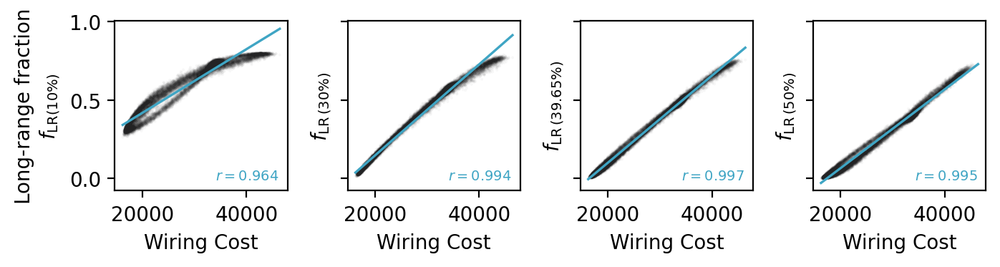

In [57]:
x_value = "wiring_cost"
thresholds = ["0.1", "0.3", "0.3956", "0.5"]
threshold_labels = ["10%", "30%", "39.65%", "50%"]

for dataset in dict_with_all_datasets.keys():
    df = dict_with_all_datasets[dataset]
    print(dataset, df.shape)
    
    fig, axs = plt.subplots(1, 4, figsize=viz.cm_to_inch((18, 5)), sharex=True, sharey=True, dpi=200)

    for i, (thresh, label) in enumerate(zip(thresholds, threshold_labels)):
        col = f"proportion_long_range_connections_{thresh}"
        
        axs[i].scatter(
            df[x_value], df[col],
            alpha=0.03 if dataset == "hcp_schaefer_100_dataset_gnm" else 0.4,  # Adjust alpha based on dataset size
            color=COLOR_SCHEME[dataset],
            edgecolor="none", s=2, rasterized=True,
        )
        
        sns.regplot(
            x=x_value, y=col, data=df,
            scatter=False, ax=axs[i],
            line_kws={"color": COLORS["colds"]["LAKE_BLUE"], "linewidth": 1.2},
        )

        r = df[[x_value, col]].corr().iloc[0, 1]
        axs[i].text( # lower right corner of the plot
            x=0.95, y=0.05,  # Adjust as needed
            s=f"$r = {r:.3f}$",
            transform=axs[i].transAxes, fontsize=7,
            color=COLORS["colds"]["LAKE_BLUE"],
            va="bottom", # top", 
            ha="right", # left",
        )
        
        # axs[i].set_title(f"Threshold: {label}", fontsize=8)
        axs[i].set_xlabel("") # "Wiring cost" if i == 1 else "")  # single shared label
        axs[i].set_xlabel(PROPERTY_NAMES[x_value]) # f"Proportion LR ({label})" if i == 0 else "")  # single shared label
        # axs[i].set_ylabel("$f_{\\mathrm{LR (10%)}}$")
        # axs[i].set_ylabel("$f_{\\mathregular{LR}(10\\%)}$")
        # axs[i].set_ylabel(f"Long-range fraction\n$f_{{\\rm LR\\,({label.replace('%', '\\%')})}}$")
        axs[i].set_yticks([])
        axs[i].set_ylabel(f"$f_{{\\rm LR\\,({label.replace('%', '\\%')})}}$")

    # axs[0].set_ylabel("Long-range fraction\n$f_{\\mathrm{LR (10%)}}$")
    axs[0].set_ylabel("Long-range fraction\n$f_{\\mathregular{LR}(10\\%)}$")
    axs[0].set_yticks([0,0.5,1])

    # Single shared x-label
    # fig.supxlabel("Wiring cost (total Euclidean distance)") # , # fontsize=8, 
                #   y=0.02)

    plt.tight_layout()
    plt.savefig(
        output_folder / f"scatter_{dataset}_wiring_cost_vs_lr_fraction.pdf",
        dpi=200, bbox_inches="tight" 
    )
    print(output_folder / f"scatter_{dataset}_wiring_cost_vs_lr_fraction.pdf")
    plt.show()
    
    break

# Remove columns of non-interest

In [58]:
# Drop "avg_clustering" in dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"] if it exists, because it is identical to "avg_clustering_static"
dict_of_metrics_to_replace = { # new_name: old_name (but new_name currently already exists...)
    "avg_clustering": "avg_clustering_static",
    "global_efficiency": "global_efficiency_dynamic",
    "avg_degree": "avg_degree_static",
    "transitivity": "transitivity_static",
    "modularity": ["modularity_static", "modularity_dup"], 
    # "wiring_cost": "wiring_cost_dup", -> tHe one without "dup" is the static one. 
}
metrics_to_remove = [] 
metrics_to_remove_because_they_are_constant = ["avg_degree_static", "avg_degree", 
                                               "n_connected_components", 
                                               "density", "density_bct", 
                                               "kernel_rank_phase_of_lambda_max", 
                                               "wiring_cost_static", # exists only for GNM, is equal to wiring_cost. 
                                               "network_idx_computational", # exist only for empirical and optimal networks
                                               "network_idx_dynamic", # exist only for empirical and optimal networks
                                               "network_idx_further", # exist only for empirical and optimal networks
                                               "global_efficiency_dup", # Drop, nearly equal to global_efficiency, see powerpoint. 
                                               "wiring_cost_dup", # -> tHe one without "dup" is the static one.
                                               ]
metrics_to_remove_because_they_are_pure_noise = ["mc_0"]
metrics_to_remove_because_they_are_numerically_unstable_and_not_computable_for_some_individual_networks = ["departure_from_normality"]

metrics_to_remove += metrics_to_remove_because_they_are_constant
metrics_to_remove += metrics_to_remove_because_they_are_pure_noise
metrics_to_remove += metrics_to_remove_because_they_are_numerically_unstable_and_not_computable_for_some_individual_networks


for dataset in dict_with_all_datasets.keys():
    print(f"Processing dataset: {dataset}")
    for metric, static_ish_metrics in dict_of_metrics_to_replace.items():
        if isinstance(static_ish_metrics, str):
            static_ish_metrics = [static_ish_metrics]  # normalise to list
        for static_ish_metric in static_ish_metrics:
            if static_ish_metric in dict_with_all_datasets[dataset].columns:
                print(static_ish_metric, "exists in", dataset, "- replacing", metric)
                dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].rename(
                    columns={static_ish_metric: metric + "_vals_to_keep"}
                )
                dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].drop(columns=[metric])
                dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].rename(
                    columns={metric + "_vals_to_keep": metric}
                )
                print(dict_with_all_datasets[dataset].keys())
                break  # stop after first match found
            

# Drop "metrics_to_remove" in all datasets 
for dataset in dict_with_all_datasets.keys():
    for metric in metrics_to_remove:
        if metric in dict_with_all_datasets[dataset].columns:
            dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].drop(columns=[metric])
            
            

Processing dataset: hcp_schaefer_100_dataset_gnm
avg_clustering_static exists in hcp_schaefer_100_dataset_gnm - replacing avg_clustering
Index(['eta', 'gamma',
       'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
       'avg_communicability', 'global_efficiency', 'modularity', 'avg_degree',
       'density_bct', 'transitivity', 'avg_edge_distance',
       ...
       'persistent_homology_ph_total_persistence',
       'targeted_attack_robustness_rob_targeted_auc',
       'targeted_attack_robustness_rob_random_auc',
       'targeted_attack_robustness_rob_ratio',
       'targeted_attack_robustness_rob_targeted_half',
       'targeted_attack_robustness_rob_random_half',
       'algebraic_connectivity_fiedler_value',
       'algebraic_connectivity_fiedler_value_norm',
       'algebraic_connectivity_laplacian_spectral_gap',
       'algebraic_connectivity_fiedler_bipartition_balance'],
      dtype='object', length=186)
global_efficiency_dynamic exists in hcp_schaefer_100_

In [59]:
# orig_keys = dict_with_all_datasets.keys()

orig_keys = [
    'hcp_schaefer_100_dataset_gnm', 
    # 'hcp_schaefer_100_dataset', 
    # 'kaysons_generated_networks_diffusion', 
    # 'kaysons_generated_networks_propagation', 
    # 'kaysons_generated_networks_routing', 
    # 'kaysons_generated_networks_topology', 
    # 'suarez_MaMI_dataset', 
    # 'lexis_data_young', 'lexis_data_aging', 'lexis_data_developing'
    
    "lexis_data_developing_consensus_per_age_1_year", 
    "lexis_data_young_consensus_per_age_1_year",
    "lexis_data_aging_consensus_per_age_1_year",
    "lexis_data_all_consensus_per_age_1_year",
    "lexis_data_all_consensus_per_age_2_year",

]

In [60]:
# Make a nice comparison table: which properties each dataset has
# Collect all unique column names across datasets
all_columns = set()
for df in dict_with_all_datasets.values():
    all_columns.update(df.columns)
all_columns = sorted(all_columns)

# Build a presence table
presence_table = pd.DataFrame(index=all_columns, columns=list(dict_with_all_datasets.keys()))
for dataset_name, df in dict_with_all_datasets.items():
    for col in all_columns:
        presence_table.loc[col, dataset_name] = "y" if col in df.columns else "missing"


presence_table.rename(columns=LABEL_MAP, inplace=True)

print("\n" + "=" * 60)
print("Property presence table:")
print(presence_table.to_string())

# Save the table to CSV
presence_table.to_csv(output_folder / "property_presence_table_filtered.csv")
print(output_folder / "property_presence_table_filtered.csv")
print("\nSaved property presence table.")


Property presence table:
                                                                 HCP (GNM) Developing (Consensus, 1 Year) Young (Consensus, 1 Year) Aging (Consensus, 1 Year) All (Consensus, 1 Year) All (Consensus, 2 Year)
MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)         y                        missing                   missing                   missing                 missing                 missing
algebraic_connectivity_fiedler_bipartition_balance                       y                              y                         y                         y                       y                       y
algebraic_connectivity_fiedler_value                                     y                              y                         y                         y                       y                       y
algebraic_connectivity_fiedler_value_norm                                y                              y                         y                   

In [61]:
import pickle

with open(output_folder / "all_datasets_filtered_lexi_age_grouped.pkl", "wb") as f:
    pickle.dump(dict_with_all_datasets, f)
    
for d in dict_with_all_datasets: 
    print(d, dict_with_all_datasets[d].shape)


hcp_schaefer_100_dataset_gnm (25000, 175)
lexis_data_developing_consensus_per_age_1_year (17, 170)
lexis_data_young_consensus_per_age_1_year (17, 171)
lexis_data_aging_consensus_per_age_1_year (57, 164)
lexis_data_all_consensus_per_age_1_year (86, 163)
lexis_data_all_consensus_per_age_2_year (44, 163)


In [62]:
import re
from config import PROPERTY_NAMES

# ── Category definitions ──────────────────────────────────────────────────────
categories = {
    "Fundamental Topology": [ 
        "transitivity", "avg_clustering", "modularity", "degree_gini", # Basic
        "degree_assortativity", "omega", "structural_complexity", 
        
        "directed_simplices_count", # Higher order
        "directed_simplices_max_size",
        
        "energy" # i.e.: Fit to networks - maybe remove again? 
    ],
    "Paths, Efficiency & Communication": [
        "char_path_length", "global_efficiency", "diffusion_efficiency",
        "propagation_efficiency", "avg_communicability",
        "topological_distance_mean", "topological_distance_std",
    ],
    "Spatial Embedding & Wiring Cost": [
        "avg_edge_distance", "wiring_cost",
        "proportion_long_range_connections_0.1",
        "proportion_long_range_connections_0.3",
        "proportion_long_range_connections_0.3956",
        "proportion_long_range_connections_0.5",
    ],
    "Rich-Club Organization": [
        "richclub_n_edges", "richclub_avg_length",
        "rich_club_coefficient_rc_max_norm",
        "rich_club_coefficient_rc_mean_norm",
        "rich_club_coefficient_rc_k_at_max",
        "rich_club_coefficient_rc_regime_frac",
        "rich_club_coefficient_rc_weighted_auc",
    ],
    "Spectral Properties, Algebraic Connectivity & Fiedler Analysis": [
        "spectral_radius", 
        # "synchronizability_eigenratio_lambda_N", # largest eigenvalue. -> spectral radius
        "spectral_gap", # Has exactly the same output as Fatemehs version, bc it is identical (lambda_n - lambda_(n-1))
        # "spectral_gap_fatemeh", 
    # ],
    # "Synchronization & Eigenratio": [
        "synchronizability_eigenratio_eigenratio", # lambda_n / lambda_2
    # ],
        "kernel_rank_thresholded_and_summed_0.01",          # np.sum(np.abs(eigs) > threshold * np.abs(eigs).max())
        # "kernel_rank_max",                                  # biggest eigenvalue
        "kernel_rank_phase_diff_of_lambda_max_and_2nd",     # np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max())
                # eigs = np.linalg.eigvals(A)
                #     "thresholded_and_summed_0.01": np.sum(np.abs(eigs) > threshold * np.abs(eigs).max()), 
                #     "max": np.abs(eigs).max(), 
                #     "phase_of_lambda_max": np.angle(eigs.max()), 
                #     "phase_diff_of_lambda_max_and_2nd": np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max()), 
                
    # "Algebraic Connectivity & Fiedler Analysis": [
        # "algebraic_connectivity_nx", # Identical to fiedler value....
        "algebraic_connectivity_fiedler_value", # Relies on a different library, I hope? 
        "algebraic_connectivity_fiedler_value_norm",
        # "synchronizability_eigenratio_lambda_2", # Should be fiedler value...  (first non-zero)
        "algebraic_connectivity_laplacian_spectral_gap",
        "algebraic_connectivity_fiedler_bipartition_balance",
        
        "departure_from_normality_schur",
                # """
                # from scipy.linalg import solve_continuous_lyapunov, schur
                # Henrici departure from normality via Schur decomposition.
                
                # For M = QTQ*, the departure equals ||T_off||_F / ||M||_F,
                # where T_off is the strictly upper-triangular part of T.
                
                # This avoids the numerically unstable subtraction
                # ||M||_F^2 - sum|lambda_i|^2 from the eigenvalue-based formula.
                # """
                # A = np.array(A, dtype=np.complex128)

                # norm_F = np.linalg.norm(A, 'fro')
                # if norm_F < 1e-12:
                #     return 0.0
                
                # # Schur decomposition: M = Q T Q^H
                # T, _ = schur(A, output='complex')

                # # Strictly upper-triangular part = non-normal component
                # T_off = np.triu(T, k=1)
                
                # return float(np.linalg.norm(T_off, 'fro') / norm_F)
            
                # ____________________________________________
                # M = np.array(M)
                # # Calculate the Frobenius norm of M
                # norm_F = linalg.norm(M, 'fro')
                # # Compute the eigenvalues of M
                # eigenvalues = np.linalg.eigvals(M)
                # # Compute the sum of the squares of the eigenvalues
                # sum_squares_eigenvalues = np.sum(np.abs(eigenvalues)**2)
                # # Compute the departure from normality
                # d_F = np.sqrt(norm_F**2 - sum_squares_eigenvalues)
                # return d_F/norm_F

        "effective_dimensionality",
                # eigs = np.linalg.eigvals(A)
                # eigs_abs = np.abs(eigs)
                # return np.sum(eigs_abs)**2 / np.sum(eigs_abs**2)
    ],
    # "Kuramoto Synchronization (Single Trial)": [
    #     "kuramoto_synchronization_r_final",
    #     "kuramoto_synchronization_r_mean",
    #     "kuramoto_synchronization_r_std",
    # ],
    "Metastability & Kuramoto Synchronization": [ # (Multi-Trial Averaged)": [
        "repertoire_sweep_weighted_by_distances_T_critical",
        "repertoire_sweep_weighted_by_distances_size_critical",
        "repertoire_sweep_weighted_by_distances_diversity_critical", 
        
        "kuramoto_averaged_synchronization_r_final",
        "kuramoto_averaged_synchronization_r_mean",
        "kuramoto_averaged_synchronization_r_mean_se",
        "kuramoto_averaged_synchronization_r_std",
        "kuramoto_averaged_synchronization_r_std_se",
    # ],
    # "Metastability": [
        # "repertoire_size", -> sweeping and weighting are very important
        # "repertoire_diversity",  -> sweeping and weighting are very important
    ],

    "Participation Coefficient (Louvain)": [
        "participation_coefficient_n_communities",
        "participation_coefficient_pc_mean",
        "participation_coefficient_pc_median",
        "participation_coefficient_pc_std",
        "participation_coefficient_pc_frac_connector",
        # "participation_coefficient_wmd_mean", 
                # # The within-module degree z-score (WMD) mean is theoretically exactly zero by construction — 
                # it's a z-score, so across all nodes within each module, the mean is always 0. 
                # What you're seeing (1e-8 range) is pure floating-point numerical noise, not a real signal.
                # This means participation_coefficient_wmd_mean is essentially uninformative and 
                # you can safely drop it. The noisy salt-and-pepper pattern in that panel is the giveaway — 
                # it looks like random rounding error, not a structured response to η/γ.
        "participation_coefficient_wmd_std",
            # The std (wmd_std) is still informative because it captures how spread the hub structure 
            # is across modules, even though the mean is anchored at zero. You can see it has a clean 
            # structured pattern in your plot.
    ],
    # "Participation Coefficient (Further Partition)": [ # exactly identical as the code above... 
    #     "participation_coefficient_n_communities_further",
    #     "participation_coefficient_pc_mean_further",
    #     "participation_coefficient_pc_median_further",
    #     "participation_coefficient_pc_std_further",
    #     "participation_coefficient_pc_frac_connector_further",
    #     "participation_coefficient_wmd_mean_further",
    #     "participation_coefficient_wmd_std_further",
    # ],
    "Ollivier-Ricci Curvature": [
        "ollivier_ricci_curvature_orc_mean",
        "ollivier_ricci_curvature_orc_median",
        "ollivier_ricci_curvature_orc_std",
        "ollivier_ricci_curvature_orc_min",
        "ollivier_ricci_curvature_orc_max",
        "ollivier_ricci_curvature_orc_skewness",
        "ollivier_ricci_curvature_orc_frac_neg",
    ],
    "Persistent Homology (TDA)": [
        # "persistent_homology_ph_h0_n_features",
        # "persistent_homology_ph_h0_persistence_mean",
        # "persistent_homology_ph_h0_persistence_std",
        # "persistent_homology_ph_h0_entropy",
        "persistent_homology_ph_h1_n_features",
        "persistent_homology_ph_h1_persistence_mean",
        # "persistent_homology_ph_h1_persistence_std",
        "persistent_homology_ph_h1_entropy",
        "persistent_homology_ph_total_persistence",
    ],

    "Targeted Attack Robustness & Community Structure & Vulnerability": [
        "targeted_attack_robustness_rob_targeted_auc",
        "targeted_attack_robustness_rob_targeted_half",
        "targeted_attack_robustness_rob_random_auc",
        "targeted_attack_robustness_rob_random_half",
        "targeted_attack_robustness_rob_ratio",
        
        "community_synchronization_vulnerability_value",
        "community_synchronization_vulnerability_n_communities",
            # Measures cross-community coupling via:
            #   1. Between/within coupling ratio — global vulnerability score (corrected).
    ],
    "Network Control Theory - Average Controllability": [
        "nct_control_avg", "nct_control_std", "nct_control_max",
        "nct_control_n_nodes_90_percent",
        "nct_control_n_nodes_50_percent",
        "nct_control_n_nodes_10_percent",
    ],
    "Network Control Theory - Control Energy": [
        "nct_energies_total", "nct_energies_std", "nct_energies_max",
        "nct_energies_n_nodes_90_percent",
        "nct_energies_n_nodes_50_percent",
        "nct_energies_n_nodes_10_percent",
    ],
    "Computational Capacity": [
        "computational_capacity_memory_capacity_total",
        "computational_capacity_memory_timescale",
        "computational_capacity_nonlinear_capacity_total",
        "computational_capacity_cubic_capacity_total",
        "computational_capacity_cross_capacity_total",
        "computational_capacity_memory_nonlinear_ratio",
        "computational_capacity_total_capacity",
        "computational_capacity_state_dimensionality",
        "computational_capacity_state_entropy",
        "computational_capacity_state_rank",
        "computational_capacity_separation_ratio",
        "computational_capacity_lyapunov_exponent",
    ],
    # "Reservoir Computing - Basic Measures": 
    "Memory Capacity - Full Lag Profile": (
        [f"mc_{i}" for i in range(1, 50)] + ["mc_mean", "mc_std", "mc_nonlinear_original_mc_mean", "mc_nonlinear_original_mc_std"]
    ),
}

# ── Coverage check ────────────────────────────────────────────────────────────
all_categorised = set(col for cols in categories.values() for col in cols)
uncategorised = [c for c in cols_of_interest if c not in all_categorised]
if uncategorised:
    print(f"⚠️  {len(uncategorised)} column(s) not assigned to any category:")
    for c in uncategorised:
        print(f"   • {c}")
else:
    print("✅  All columns covered.")

# ── Helper: pretty-wrap long titles ──────────────────────────────────────────
def wrap_title(col: str, max_len: int = 20) -> str:
    if len(col) <= max_len:
        return col
    parts = re.split(r'[_,]+', col)
    mid = len(parts) // 2
    return "_".join(parts[:mid]) + "\n" + "_".join(parts[mid:])

# ── Plot one figure per category ──────────────────────────────────────────────
n_cols = 4

for cat_name, cat_cols in categories.items():
    # keep only columns that actually exist in the dataframe
    present = [c for c in cat_cols if c in df_gnm_g.columns]
    if not present:
        print(f"⚠️  Skipping '{cat_name}' - no columns found in dataframe.")
        continue

    n_rows = (len(present) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols, 
        figsize=viz.cm_to_inch((n_cols * 3.5, n_rows * 3.5)),
        sharex=True, sharey=True,
        dpi=200,
    )
    # normalise axes to always be 2-D
    axes = np.array(axes).reshape(n_rows, n_cols)

    fig.suptitle(cat_name, fontsize=8, fontweight="bold", y=1.01)

    for idx, col in enumerate(present):
        ax = axes[idx // n_cols, idx % n_cols]
        pivoted = df_gnm_g.pivot(index="gamma", columns="eta", values=col)
        vabs = np.nanmax(np.abs(pivoted.values))  # symmetric around 0
        im = ax.imshow(
            pivoted,
            aspect="equal",
            origin="lower",
            cmap="RdBu_r",
            # vmin=-vabs, vmax=vabs, 
        )
        ax.set_title(wrap_title(PROPERTY_NAMES[col]), fontsize=5)
        ax.set_xticks([])
        ax.set_yticks([])
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=4)
        # The next line forces the e-notation to be at the ticks, such that the labels don't collide with the title. 
        cbar.ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x:.1e}")
        )

    # remove unused axes
    for idx in range(len(present), n_rows * n_cols):
        fig.delaxes(axes[idx // n_cols, idx % n_cols])

    plt.tight_layout(pad=0.5)

    safe_name = re.sub(r'[^\w]+', '_', cat_name).strip('_').lower()
    out_path = output_folder / f"gnm_heatmaps_{safe_name}.pdf"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(out_path)

⚠️  31 column(s) not assigned to any category:
   • MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)
   • mc_0
   • avg_clustering_static
   • avg_degree_static
   • modularity_static
   • transitivity_static
   • wiring_cost_static
   • global_efficiency_dynamic
   • synchronizability_eigenratio_lambda_2
   • synchronizability_eigenratio_lambda_N
   • spectral_gap_fatemeh
   • kuramoto_synchronization_r_final
   • kuramoto_synchronization_r_mean
   • kuramoto_synchronization_r_std
   • participation_coefficient_wmd_mean
   • algebraic_connectivity_nx
   • kernel_rank_max
   • repertoire_size
   • repertoire_diversity
   • participation_coefficient_pc_mean_further
   • participation_coefficient_pc_std_further
   • participation_coefficient_pc_median_further
   • participation_coefficient_pc_frac_connector_further
   • participation_coefficient_wmd_mean_further
   • participation_coefficient_wmd_std_further
   • participation_coefficient_n_communities_further
   • persis

In [63]:
categories 


{'Fundamental Topology': ['transitivity',
  'avg_clustering',
  'modularity',
  'degree_gini',
  'degree_assortativity',
  'omega',
  'structural_complexity',
  'directed_simplices_count',
  'directed_simplices_max_size',
  'energy'],
 'Paths, Efficiency & Communication': ['char_path_length',
  'global_efficiency',
  'diffusion_efficiency',
  'propagation_efficiency',
  'avg_communicability',
  'topological_distance_mean',
  'topological_distance_std'],
 'Spatial Embedding & Wiring Cost': ['avg_edge_distance',
  'wiring_cost',
  'proportion_long_range_connections_0.1',
  'proportion_long_range_connections_0.3',
  'proportion_long_range_connections_0.3956',
  'proportion_long_range_connections_0.5'],
 'Rich-Club Organization': ['richclub_n_edges',
  'richclub_avg_length',
  'rich_club_coefficient_rc_max_norm',
  'rich_club_coefficient_rc_mean_norm',
  'rich_club_coefficient_rc_k_at_max',
  'rich_club_coefficient_rc_regime_frac',
  'rich_club_coefficient_rc_weighted_auc'],
 'Spectral Pro

In [64]:
precise_categories = []

for cat_name, cat_cols in categories.items(): 
    
    if cat_name == "Memory Capacity - Full Lag Profile": 
        precise_categories.append("mc_mean")
        continue
    
    for col in cat_cols:
        
        if col == "energy": 
            continue 
        
        precise_categories.append(col)
        
precise_categories

# Save this as precise_categories (pkl) 
with open(output_folder / "precise_categories_lexi_age_grouped.pkl", "wb") as f:
    pickle.dump(precise_categories, f)


In [65]:
# Get only the columns in "precise_categories" from dict_with_all_datasets, and save this as dict_with_all_datasets_precise_categories (pkl)
dict_with_all_datasets_precise_categories = {}
for dataset, df in dict_with_all_datasets.items():
    cols_to_keep = [col for col in precise_categories if col in df.columns]
    dict_with_all_datasets_precise_categories[dataset] = df[cols_to_keep]

with open(output_folder / "all_datasets_precise_categories_lexi_age_grouped.pkl", "wb") as f:
    pickle.dump(dict_with_all_datasets_precise_categories, f)
    

In [66]:

print(output_folder / "all_datasets_precise_categories_lexi_age_grouped.pkl")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis_lexi_age_grouped/all_datasets_precise_categories_lexi_age_grouped.pkl


In [67]:
for d in dict_with_all_datasets_precise_categories: 
    print(d, dict_with_all_datasets_precise_categories[d].shape) # , dict_with_all_datasets_precise_categories[d].columns)

hcp_schaefer_100_dataset_gnm (25000, 97)
lexis_data_developing_consensus_per_age_1_year (17, 97)
lexis_data_young_consensus_per_age_1_year (17, 97)
lexis_data_aging_consensus_per_age_1_year (57, 90)
lexis_data_all_consensus_per_age_1_year (86, 90)
lexis_data_all_consensus_per_age_2_year (44, 90)


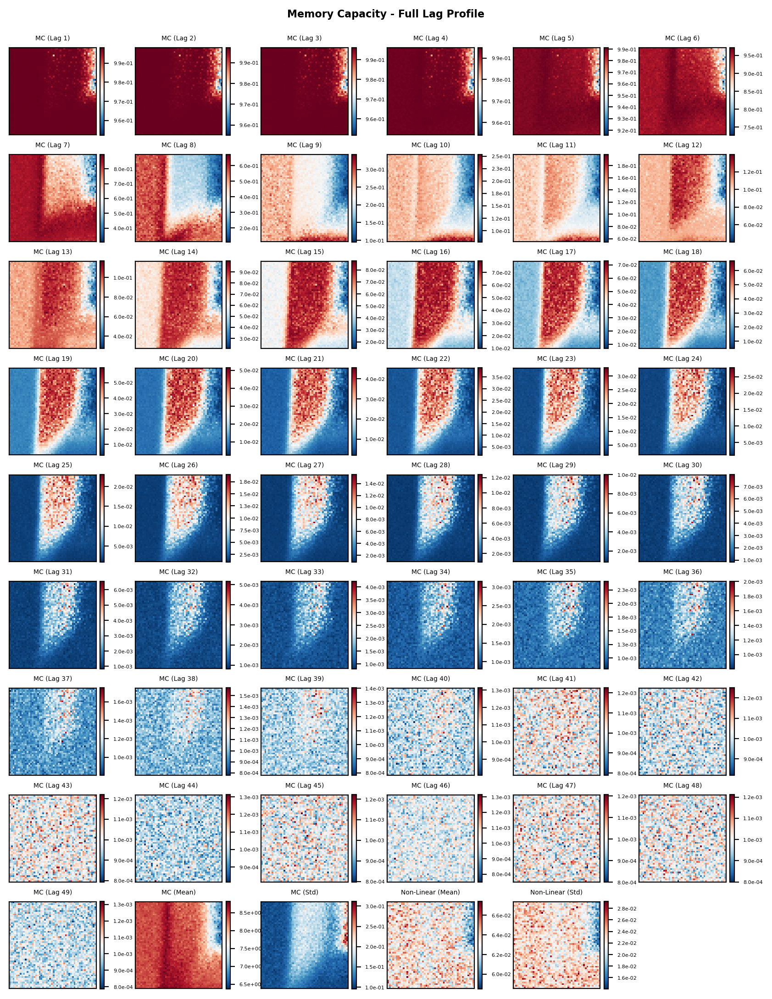

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis_lexi_age_grouped/gnm_heatmaps_memory_capacity_full_lag_profile.pdf


In [68]:



# ── Plot one figure per category ──────────────────────────────────────────────
n_cols = 6

cat_name = "Memory Capacity - Full Lag Profile"
cat_cols = categories[cat_name]

n_rows = (len(present) + n_cols - 1) // n_cols
fig, axes = plt.subplots(
n_rows, n_cols, 
# figsize=viz.cm_to_inch((n_cols * 3.5, n_rows * 3.5)),
figsize=viz.cm_to_inch((n_cols * 3.5, n_rows * 3)),
sharex=True, sharey=True,
dpi=200,
)
# normalise axes to always be 2-D
axes = np.array(axes).reshape(n_rows, n_cols)

fig.suptitle(cat_name, fontsize=8, fontweight="bold", y=1.01)

for idx, col in enumerate(present):
    ax = axes[idx // n_cols, idx % n_cols]
    pivoted = df_gnm_g.pivot(index="gamma", columns="eta", values=col)
    vabs = np.nanmax(np.abs(pivoted.values))  # symmetric around 0
    im = ax.imshow(
        pivoted,
        aspect="equal",
        origin="lower",
        cmap="RdBu_r",
        # vmin=-vabs, vmax=vabs, 
    )
    ax.set_title(wrap_title(PROPERTY_NAMES[col]), fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=4)
    # The next line forces the e-notation to be at the ticks, such that the labels don't collide with the title. 
    cbar.ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.1e}")
    )

# remove unused axes
for idx in range(len(present), n_rows * n_cols):
    fig.delaxes(axes[idx // n_cols, idx % n_cols])

plt.tight_layout(pad=0.2)

safe_name = re.sub(r'[^\w]+', '_', cat_name).strip('_').lower()
out_path = output_folder / f"gnm_heatmaps_{safe_name}.pdf"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(out_path)